In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix # Added classification_report and confusion_matrix
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Import advanced models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

In [2]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [3]:
# Save PassengerId for submission
test_ids = test_df['PassengerId']

# Drop irrelevant features
train_df.drop(['PassengerId', 'Name'], axis=1, inplace=True)
test_df.drop(['PassengerId', 'Name'], axis=1, inplace=True)

In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HomePlanet    8492 non-null   object 
 1   CryoSleep     8476 non-null   object 
 2   Cabin         8494 non-null   object 
 3   Destination   8511 non-null   object 
 4   Age           8514 non-null   float64
 5   VIP           8490 non-null   object 
 6   RoomService   8512 non-null   float64
 7   FoodCourt     8510 non-null   float64
 8   ShoppingMall  8485 non-null   float64
 9   Spa           8510 non-null   float64
 10  VRDeck        8505 non-null   float64
 11  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(5)
memory usage: 755.7+ KB


In [5]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HomePlanet    4190 non-null   object 
 1   CryoSleep     4184 non-null   object 
 2   Cabin         4177 non-null   object 
 3   Destination   4185 non-null   object 
 4   Age           4186 non-null   float64
 5   VIP           4184 non-null   object 
 6   RoomService   4195 non-null   float64
 7   FoodCourt     4171 non-null   float64
 8   ShoppingMall  4179 non-null   float64
 9   Spa           4176 non-null   float64
 10  VRDeck        4197 non-null   float64
dtypes: float64(6), object(5)
memory usage: 367.7+ KB


In [6]:
train_df.head()

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported
0,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False
1,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True
2,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False
3,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False
4,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True


In [7]:
y = train_df['Transported'].astype(bool).astype(int)

In [8]:
# Handle Cabin feature
for df in [train_df, test_df]:
    if 'Cabin' in df.columns:
        df[['Deck', 'CabinNum', 'Side']] = df['Cabin'].str.split('/', expand=True)
        df.drop('Cabin', axis=1, inplace=True)
        df['CabinNum'] = df['CabinNum'].fillna('-1').astype(int)

In [9]:
# Feature engineering
for df in [train_df, test_df]:
    df['TotalSpending'] = df[['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']].sum(axis=1)
    df['GroupSize'] = df['CabinNum'].apply(lambda x: x if x != -1 else 0)
    df['SpendingPerService'] = df['TotalSpending'] / 5
    df['IsAlone'] = df['GroupSize'].apply(lambda x: 1 if x <= 2 else 0)
    # Ensure 'IsAlone' is of numeric type
    df['IsAlone'] = df['IsAlone'].astype(int)


In [10]:
# Fill missing values
imputer = SimpleImputer(strategy='most_frequent')
train_features = train_df.drop('Transported', axis=1)
train_df = pd.DataFrame(imputer.fit_transform(train_features), columns=train_features.columns)
test_df = pd.DataFrame(imputer.transform(test_df), columns=test_df.columns)

In [11]:
# Encode categorical features
label_enc = LabelEncoder()
categorical_features = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side']

for col in categorical_features:
    train_df[col] = label_enc.fit_transform(train_df[col].astype(str))
    test_df[col] = label_enc.transform(test_df[col].astype(str))

In [12]:
train_df.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Deck,CabinNum,Side,TotalSpending,GroupSize,SpendingPerService,IsAlone
0,1,0,2,39.0,0,0.0,0.0,0.0,0.0,0.0,1,0,0,0.0,0,0.0,1
1,0,0,2,24.0,0,109.0,9.0,25.0,549.0,44.0,5,0,1,736.0,0,147.2,1
2,1,0,2,58.0,1,43.0,3576.0,0.0,6715.0,49.0,0,0,1,10383.0,0,2076.6,1
3,1,0,2,33.0,0,0.0,1283.0,371.0,3329.0,193.0,0,0,1,5176.0,0,1035.2,1
4,0,0,2,16.0,0,303.0,70.0,151.0,565.0,2.0,5,1,1,1091.0,1,218.2,1


In [13]:
X_train, X_val, y_train, y_val = train_test_split(train_df, y, test_size=0.2, random_state=42)

**Random Forest**

In [14]:
# Train the model
model = RandomForestClassifier(random_state=42, n_estimators=200, max_depth=10)
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

In [15]:
# Evaluate the model
y_pred_rm = model.predict(X_val)
accuracy = accuracy_score(y_val, y_pred_rm)
print(f"Validation Accuracy: {accuracy:.4f}")

Validation Accuracy: 0.7924


In [16]:
# Additional evaluation metrics
print("\nClassification Report:")
print(classification_report(y_val, y_pred_rm))


Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.78      0.79       861
           1       0.79      0.81      0.80       878

    accuracy                           0.79      1739
   macro avg       0.79      0.79      0.79      1739
weighted avg       0.79      0.79      0.79      1739



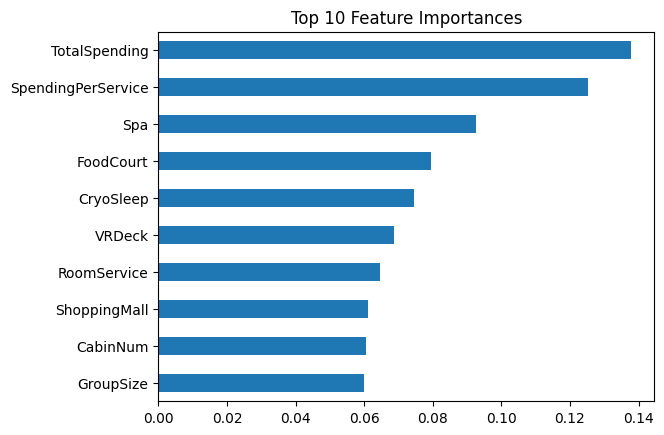

In [17]:
# Feature Importance Visualization
feature_importance = pd.Series(model.feature_importances_, index=X_train.columns)
feature_importance.nlargest(10).sort_values().plot(kind='barh', title="Top 10 Feature Importances")
plt.show()

In [18]:
#Predict on the test set
test_predictions = model.predict(test_df)

# Create submission file
submission = pd.DataFrame({
    'PassengerId': test_ids,
    'Transported': test_predictions.astype(bool)
})
submission.to_csv('submission.csv', index=False)
print("Submission file created.")

Submission file created.


**MLP**

In [19]:
# Train MLP Classifier
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)
mlp_model.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(128, 64, 32), max_iter=500, random_state=42)

In [20]:
# Evaluate MLP Classifier
y_pred_mlp = mlp_model.predict(X_val)
print(f"MLP Classifier Validation Accuracy: {accuracy_score(y_val, y_pred_mlp):.4f}")
print("\nClassification Report (MLP Classifier):")
print(classification_report(y_val, y_pred_mlp))

MLP Classifier Validation Accuracy: 0.7516

Classification Report (MLP Classifier):
              precision    recall  f1-score   support

           0       0.84      0.61      0.71       861
           1       0.70      0.89      0.78       878

    accuracy                           0.75      1739
   macro avg       0.77      0.75      0.75      1739
weighted avg       0.77      0.75      0.75      1739



In [21]:
# Predict on the test set using MLP Classifier
test_predictions = mlp_model.predict(test_df)

# Create submission file
submission = pd.DataFrame({
    'PassengerId': test_ids,
    'Transported': test_predictions.astype(bool)
})
submission.to_csv('submission.csv', index=False)
print("Submission file created.")

Submission file created.


**XGBoost**

In [22]:
print(X_train.dtypes)

HomePlanet             int64
CryoSleep              int64
Destination            int64
Age                   object
VIP                    int64
RoomService           object
FoodCourt             object
ShoppingMall          object
Spa                   object
VRDeck                object
Deck                   int64
CabinNum              object
Side                   int64
TotalSpending         object
GroupSize             object
SpendingPerService    object
IsAlone               object
dtype: object


In [23]:
# Convert numeric strings to float
numeric_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'CabinNum', 'TotalSpending', 'GroupSize', 'SpendingPerService', 'IsAlone']
X_train[numeric_cols] = X_train[numeric_cols].apply(pd.to_numeric, errors='coerce')
X_val[numeric_cols] = X_val[numeric_cols].apply(pd.to_numeric, errors='coerce')

In [24]:
# Train XGBoost
xgb_model = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=7, random_state=42)
xgb_model.fit(X_train, y_train)

# Evaluate XGBoost
y_pred_xgb = xgb_model.predict(X_val)
print(f"XGBoost Validation Accuracy: {accuracy_score(y_val, y_pred_xgb):.4f}")
print("\nClassification Report (XGBoost):")
print(classification_report(y_val, y_pred_xgb))

XGBoost Validation Accuracy: 0.8114

Classification Report (XGBoost):
              precision    recall  f1-score   support

           0       0.81      0.81      0.81       861
           1       0.81      0.81      0.81       878

    accuracy                           0.81      1739
   macro avg       0.81      0.81      0.81      1739
weighted avg       0.81      0.81      0.81      1739



## Learning rate optimization

In [25]:
learning_rates = np.arange(0,0.1,0.01).tolist()

accuracies = []
precisions = []
recalls = []

for l_rate in learning_rates:
    xgb = XGBClassifier(n_estimators=300, learning_rate=l_rate, max_depth=10, random_state=42)
    xgb.fit(X_train, y_train)
    predictions = xgb.predict(X_val)
    accuracy = accuracy_score(y_val, predictions)
    precision = precision_score(y_val, predictions)
    recall = recall_score(y_val, predictions)

    accuracies.append(accuracy)
    precisions.append(precision)
    recalls.append(recall)

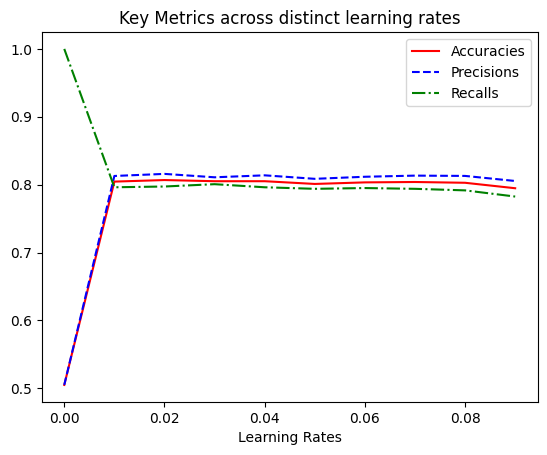

In [26]:
plt.plot(learning_rates, accuracies, label='Accuracies', color='red', linestyle='-')
plt.plot(learning_rates, precisions, label='Precisions', color='blue', linestyle='--')
plt.plot(learning_rates, recalls, label='Recalls', color='green', linestyle='-.')
plt.title('Key Metrics across distinct learning rates')
plt.xlabel('Learning Rates')

plt.legend()
plt.show()

## Maximum Depth Optimization

In [27]:
depths = np.arange(0,20,1).tolist()

accuracies = []
precisions = []
recalls = []

for d in depths:
    xgb = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=d, random_state=42)
    xgb.fit(X_train, y_train)
    predictions = xgb.predict(X_val)
    accuracy = accuracy_score(y_val, predictions)
    precision = precision_score(y_val, predictions)
    recall = recall_score(y_val, predictions)

    accuracies.append(accuracy)
    precisions.append(precision)
    recalls.append(recall)

In [28]:
depths[accuracies.index(max(accuracies))]

7

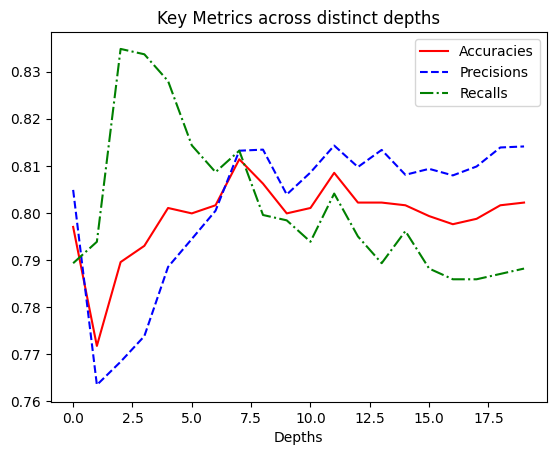

In [29]:
plt.plot(depths, accuracies, label='Accuracies', color='red', linestyle='-')
plt.plot(depths, precisions, label='Precisions', color='blue', linestyle='--')
plt.plot(depths, recalls, label='Recalls', color='green', linestyle='-.')
plt.title('Key Metrics across distinct depths')
plt.xlabel('Depths')

plt.legend()
plt.show()

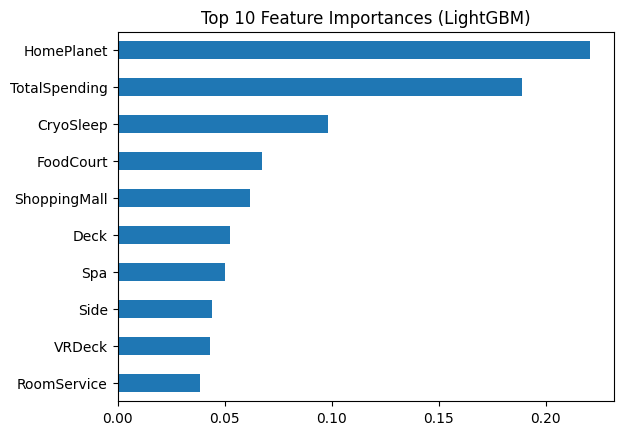

In [30]:
# Feature Importance Visualization for LightGBM
feature_importance = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
feature_importance.nlargest(10).sort_values().plot(kind='barh', title="Top 10 Feature Importances (LightGBM)")
plt.show()

In [31]:
# Convert numeric strings to float
numeric_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'CabinNum', 'TotalSpending', 'GroupSize', 'SpendingPerService', 'IsAlone']
test_df[numeric_cols] = test_df[numeric_cols].apply(pd.to_numeric, errors='coerce')

In [32]:
# Predict on the test set using the best model
test_predictions = xgb_model.predict(test_df)

# Create submission file
submission = pd.DataFrame({
    'PassengerId': test_ids,
    'Transported': test_predictions.astype(bool)
})
submission.to_csv('submission.csv', index=False)
print("Submission file created.")

Submission file created.
